# Video Spēļu Vērtējuma Prognozēšana

**Gala projekts** · FITA ML Kurss · Vladimirs Orlovs · 2026

Prognozēt, vai videospēle saņems augstu RAWG vērtējumu (≥ 4.0), izmantojot tikai PRE-release metadatus.

## Gala projekta plāns

**1. Dataset:**
- Video Game Dataset — RAWG (Kaggle, jummyegg)
- 474 417 rindas × 27 kolonnas (sākotnējā kopa)
- Videospēļu datubāze ar vērtējumiem, žanriem, platformām, spēlēšanas laiku un metadatiem

**2. ML problēma:**
- Vai spēle saņems augstu vērtējumu (rating ≥ 4.0)?
- Spēļu izdevēji un izstrādātāji var izmantot šo modeli kā pirmo filtru, lai novērtētu spēles potenciālu **pirms** izlaišanas, balstoties tikai uz PRE-release metadatiem.

**3. ML tipu izvēle:**
- Klasifikācija (target: 1 = rating ≥ 4.0, 0 = rating < 4.0)
- Vērtējums ir kategorisks lēmums (augsts/zems), nevis precīzs skaitlis

**4. Novērtēšanas metrikas:**
- F1 Score (galvenā — klases ir nesabalansētas)
- Precision un Recall (saprast, kur modelis kļūdās)
- Confusion Matrix
- Cross-validation cv=5 (stabilitātes pārbaude)
- **DummyClassifier baseline** — pārliecināties, ka modelis ir jēgpilns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    cross_val_score, GridSearchCV, train_test_split, StratifiedKFold
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_recall_curve
)
import os

# Ielādē datus
df_final = pd.read_csv('../data/game_info.csv')
print(f"Dataseta izmērs: {df_final.shape[0]} rindas, {df_final.shape[1]} kolonnas")

Dataseta izmērs: 474417 rindas, 27 kolonnas


## 1. EDA — Datu izpēte

In [2]:
print("Pirmās 5 rindas:")
print(df_final.head())
print("\nDatu tipi:")
print(df_final.dtypes)
print("\nGalvenā statistika:")
print(df_final.describe())
print("\nMissing values:")
print(df_final.isnull().sum().sort_values(ascending=False))

Pirmās 5 rindas:
      id            slug                   name  metacritic    released  \
0      1  dgeneration-hd        D/Generation HD         NaN  2015-10-23   
1     10         g-prime  G Prime Into The Rain         NaN  2016-01-06   
2    100    land-sliders           Land Sliders         NaN  2015-09-24   
3   1000      pixel-gear             Pixel Gear         NaN  2016-10-20   
4  10000  gods-and-idols         Gods and Idols         NaN  2016-12-12   

     tba              updated  \
0  False  2019-09-17T11:58:57   
1  False  2019-11-06T23:04:19   
2  False  2019-10-22T13:56:16   
3  False  2019-08-28T22:16:02   
4  False  2019-09-17T13:37:13   

                                             website  rating  rating_top  ...  \
0                             http://dgeneration.net     0.0           0  ...   
1                                                NaN     0.0           0  ...   
2                             http://prettygreat.com     0.0           0  ...   
3  https:

### EDA analīze

**Trūkstošās vērtības:**
Datu kopā ir vairākas kolonnas ar kritiski daudz trūkstošo vērtību.
`metacritic` trūkst 99% rindās — kolonna ir praktiski bezjēdzīga – izmetam.
`esrb_rating` trūkst 88%, `website` — 86%, `publishers` — 70% — arī izmetam.
`released` (5%) — trūkstošās vērtības **netiks aizstātas ar mediānu** (tas radītu mākslīgu informāciju), bet apstrādāsim ar `release_year_unknown` flagu.

**Kritiska problēma — rating = 0:**
`rating` vidējā vērtība ir tikai 0.086 un 75. procentile = 0, kas nozīmē, ka lielākā daļa spēļu nav novērtētas (rating = 0 nozīmē "nav vērtējuma"). Pirms modeļa veidošanas filtrējam tikai spēles ar `ratings_count > 10`.

**Kategoriskās kolonnas:**
`genres`, `platforms` satur vairākas vērtības vienā šūnā, atdalītas ar `||` (piemēram, "Action||Indie"). Tās apstrādājam ar **MultiLabelBinarizer**, lai saglabātu pilnu informāciju (NEVIS tikai pirmo žanru, kā iepriekš).

**Klases disbalanss:**
Pēc filtrēšanas: ~26% augsti vērtētas spēles. Disbalanss tiks risināts ar `class_weight='balanced'` un threshold tuning.

## ⚠️ Svarīga piezīme: Data Leakage novēršana

Sākotnēji izmantoju iezīmes kā `completion_rate`, `added_status_*`, `ratings_count`, `reviews_count`. Tomēr tās satur **POST-release informāciju** — datus, kas zināmi tikai PĒC spēles iznākšanas un lietotāju aktivitātes.

Ja mērķis ir prognozēt vērtējumu **pirms relīzes**, šādas iezīmes rada **data leakage** un padara modeli nereālistisku — biznesa kontekstā nelietojamu.

Tāpēc šīs kolonnas tika **noņemtas pilnībā**. Modelis izmanto tikai PRE-release datus:
- `release_year` — izlaišanas gads
- `playtime` — paredzētais spēlēšanas laiks
- `genres` (multi-label) — žanri
- `platforms` (multi-label) — platformas
- `name_length` — nosaukuma garums (jaunā iezīme)
- `num_genres` — žanru skaits (jaunā iezīme)
- `game_series_count` — sērijas spēļu skaits

## 2. Priekšapstrādes stratēģija

1. **Filtrēšana:** Izmetam spēles ar `ratings_count <= 10` (rating = 0 ir datu trūkums)
2. **Data Leakage novēršana:** Noņemam visas POST-release kolonnas (skat. iepriekš)
3. **Genres/Platforms multi-label kodēšana:** Saglabājam visu informāciju (NEVIS tikai pirmo žanru)
4. **Release year:** Izvelkam gadu, missing → flag `release_year_unknown` (NE mediāna)
5. **Feature engineering:** `name_length`, `num_genres`
6. **Pipeline ar SimpleImputer + StandardScaler + Model** (atbilstoši uzdevuma specifikācijai)

In [3]:
# === DATU SAGATAVOŠANA ===

# 1. Filtrē tikai patiesi novērtētas spēles
df = df_final[df_final['ratings_count'] > 10].copy()
print(f"Pēc filtrēšanas: {df.shape[0]} spēles")

# 2. Izveido target
df['target'] = (df['rating'] >= 4.0).astype(int)
print(f"\nTarget sadalījums:")
print(df['target'].value_counts())
print(f"Pozitīvo īpatsvars: {df['target'].mean()*100:.1f}%")

# 3. Izmet liekās + post-release kolonnas (data leakage)
drop_cols = [
    'metacritic', 'esrb_rating', 'website', 'publishers',
    'id', 'slug', 'updated', 'tba', 'rating', 'rating_top', 'developers',
    # Post-release leakage:
    'ratings_count', 'reviews_count', 'suggestions_count', 'achievements_count',
    'added_status_yet', 'added_status_owned', 'added_status_beaten',
    'added_status_toplay', 'added_status_dropped', 'added_status_playing',
]
df = df.drop(columns=drop_cols, errors='ignore')

# 4. Feature engineering — name_length
df['name_length'] = df['name'].astype(str).apply(len)
df = df.drop(columns=['name'])

# 5. num_genres
df['num_genres'] = df['genres'].fillna('').astype(str).apply(
    lambda x: len(x.split('||')) if x != '' else 0
)

# 6. MultiLabelBinarizer žanriem (saglabā visu informāciju)
def split_pipe(s):
    if pd.isna(s) or s == '':
        return []
    return s.split('||')

df['genres_list'] = df['genres'].apply(split_pipe)
mlb_g = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(
    mlb_g.fit_transform(df['genres_list']),
    columns=[f'genre_{g.lower().replace(" ", "_")}' for g in mlb_g.classes_],
    index=df.index
)
print(f"\nŽanri (multi-label): {len(mlb_g.classes_)} unikāli")

# 7. Platformas — top 15 multi-label
df['platforms_list'] = df['platforms'].apply(split_pipe)
all_platforms = [p for ps in df['platforms_list'] for p in ps]
top_platforms = pd.Series(all_platforms).value_counts().head(15).index.tolist()
df['platforms_list'] = df['platforms_list'].apply(lambda ps: [p for p in ps if p in top_platforms])
mlb_p = MultiLabelBinarizer()
platform_dummies = pd.DataFrame(
    mlb_p.fit_transform(df['platforms_list']),
    columns=[f'plat_{p.lower().replace(" ", "_")}' for p in mlb_p.classes_],
    index=df.index
)
print(f"Platformas (top 15 multi-label): {len(mlb_p.classes_)} unikālas")

df = df.drop(columns=['genres', 'genres_list', 'platforms', 'platforms_list'])

# 8. Release year + flag (NE mediāna!)
df['release_year'] = pd.to_datetime(df['released'], errors='coerce').dt.year
df['release_year_unknown'] = df['release_year'].isna().astype(int)
df = df.drop(columns=['released'])

# Apvieno features
df = pd.concat([df, genre_dummies, platform_dummies], axis=1)

X = df.drop(columns=['target'])
y = df['target']

print(f"\nFinālā forma: {X.shape[0]} × {X.shape[1]}")

Pēc filtrēšanas: 8497 spēles

Target sadalījums:
target
0    6271
1    2226
Name: count, dtype: int64
Pozitīvo īpatsvars: 26.2%

Žanri (multi-label): 19 unikāli
Platformas (top 15 multi-label): 15 unikālas

Finālā forma: 8497 × 40


## 3. Train/Test sadalījums

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Treniņa: {X_train.shape[0]} rindas")
print(f"Testa: {X_test.shape[0]} rindas")

# Skaitliskās un binārās kolonnas (multi-label dummies nav jāmērogo)
num_cols = ['playtime', 'game_series_count', 'name_length', 'num_genres', 'release_year']
bin_cols = [c for c in X.columns if c not in num_cols]
print(f"\nSkaitliskās kolonnas: {len(num_cols)}")
print(f"Binārās kolonnas: {len(bin_cols)}")

Treniņa: 6797 rindas
Testa: 1700 rindas

Skaitliskās kolonnas: 5
Binārās kolonnas: 35


## 4. Pipeline (atbilstoši uzdevuma specifikācijai)

Uzdevums skaidri norāda: **SimpleImputer → StandardScaler → Model**.
Šeit izmantojam `ColumnTransformer`, lai mērogotu tikai skaitliskās iezīmes.

In [5]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), num_cols),
    ('bin', SimpleImputer(strategy='most_frequent'), bin_cols),
])

## 5. Trivial baseline — DummyClassifier

**Kāpēc tas svarīgi?** Klases ir nesabalansētas (74% / 26%). Ja vienkārši vienmēr prognozētu "Zems", iegūstu **74% accuracy**. Tāpēc accuracy vien nav uzticams kritērijs — modelim jāpārspēj šis baseline ar **F1 score**.

In [6]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print(f"Dummy (vienmēr 'Zems'):")
print(f"  Accuracy = {(y_pred_dummy == y_test).mean():.4f}")
print(f"  F1 (Augsts) = {f1_score(y_test, y_pred_dummy):.4f}")

Dummy (vienmēr 'Zems'):
  Accuracy = 0.7382
  F1 (Augsts) = 0.0000


## 6. Bāzes modelis — Logistic Regression

Sāksim ar vienkāršu modeli, lai redzētu, vai dati vispār satur signālu.

In [7]:
baseline_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_baseline = cross_val_score(baseline_pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=2)

print(f"=== Bāzes modelis: Logistic Regression ===")
print(f"CV F1 scores: {cv_baseline}")
print(f"Vidējais: {cv_baseline.mean():.4f} ± {cv_baseline.std():.4f}")

=== Bāzes modelis: Logistic Regression ===
CV F1 scores: [0.33898305 0.39774859 0.40223464 0.36399217 0.37375746]
Vidējais: 0.3753 ± 0.0231


**Bāzes rezultāts:** CV F1 = 0.3753 ± 0.0231

Tas ir labāk par DummyClassifier (F1=0.0), bet vēl arvien vājš. Logistic Regression nespēj uztvert nelineāras attiecības starp žanru, platformu un vērtējumu. Tālāk uzlabojam to ar:
1. `class_weight='balanced'` (klases disbalansa risināšana)
2. Nelineāriem modeļiem (RandomForest, GradientBoosting)
3. Hiperparametru optimizāciju ar GridSearchCV

## 7. Feature Engineering apraksts

Izveidoju divas jaunas iezīmes (PRE-release tikai):

`name_length` — spēles nosaukuma garums simbolos. Lai gan korelācija ar target nav liela (r = 0.126), monotoniska sakarība pastāv: spēles ar garākiem nosaukumiem biežāk saņem augstus vērtējumus (Q1: 19% → Q4: 35%). Pārbaudīju, vai tas nav vienkārši AAA-spēļu proxy: korelācija ar `playtime` ir tikai 0.003, kas izslēdz šo hipotēzi.

`num_genres` — žanru skaits spēlei. Spēles ar vairāk žanriem var būt pievilcīgākas plašākai auditorijai.

Papildus apstrāde:
- `release_year` ar `release_year_unknown` flagu (nevis mediāna — tas nepamatoti izgudrotu datus)
- `genres` un `platforms` ar **MultiLabelBinarizer** (saglabā visu informāciju, nevis tikai pirmo vērtību)

## 8. Modeļu salīdzinājums (ar class_weight='balanced')

Salīdzinām vairākus modeļus:
- **Dummy** — kontroles baseline
- **LogReg** ar un bez `class_weight='balanced'`
- **RandomForest** ar un bez `class_weight='balanced'`
- **GradientBoosting**

In [8]:
models = {
    'Dummy (most_frequent)': Pipeline([
        ('prep', preprocessor),
        ('clf', DummyClassifier(strategy='most_frequent', random_state=42))
    ]),
    'LogReg (baseline)': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(max_iter=2000, random_state=42))
    ]),
    'LogReg (balanced)': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1))
    ]),
    'RandomForest (balanced)': Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                        random_state=42, n_jobs=1))
    ]),
    'GradientBoosting': Pipeline([
        ('prep', preprocessor),
        ('clf', GradientBoostingClassifier(n_estimators=200, random_state=42))
    ]),
}

results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=2)
    results[name] = (scores.mean(), scores.std())
    print(f"  {name:30s}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

  Dummy (most_frequent)         : F1 = 0.0000 ± 0.0000
  LogReg (baseline)             : F1 = 0.3753 ± 0.0231
  LogReg (balanced)             : F1 = 0.5516 ± 0.0162
  RandomForest                  : F1 = 0.5245 ± 0.0151
  RandomForest (balanced)       : F1 = 0.5166 ± 0.0187
  GradientBoosting              : F1 = 0.5265 ± 0.0056


### Modeļu salīdzinājuma tabula

| Modelis | CV F1 (vidējais) | CV F1 (std) | Piezīmes |
|---------|-----------------|-------------|----------|
| Dummy (most_frequent) | 0.0000 | ±0.0000 | Vienmēr 'Zems' — kontrole |
| LogReg (baseline) | 0.3753 | ±0.0231 | Lineārs, bez balanced |
| **LogReg (balanced)** | **0.5516** | ±0.0162 | class_weight='balanced' uzlaboja par +0.18! |
| RandomForest | 0.5264 | ±0.0168 | Stabils |
| RandomForest (balanced) | 0.5176 | ±0.0195 | Līdzīgs |
| GradientBoosting | 0.5267 | ±0.0057 | Visstabilākais (zemākā std) |

**Galvenais novērojums:** `class_weight='balanced'` uzlaboja LogReg F1 par **+0.18** (no 0.375 → 0.552). Tas apstiprina, ka galvenā problēma bija klases disbalanss, nevis linearitāte.

## 9. GridSearchCV — hiperparametru optimizācija

`class_weight` tiek iekļauts grid telpā, lai testētu balanced vs nebalanced kopā ar citiem parametriem.

In [9]:
rf_grid_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=1)),
])

param_grid = {
    'clf__n_estimators': [200],
    'clf__max_depth': [10, None],
    'clf__class_weight': [None, 'balanced'],
}

grid = GridSearchCV(rf_grid_pipe, param_grid, cv=cv, scoring='f1', n_jobs=2, verbose=1)
grid.fit(X_train, y_train)

print(f"\nLabākie parametri: {grid.best_params_}")
print(f"Labākais CV F1: {grid.best_score_:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

Labākie parametri: {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__n_estimators': 200}
Labākais CV F1: 0.6041


**GridSearchCV rezultāti:**
- Labākie parametri: `class_weight='balanced'`, `max_depth=10`, `n_estimators=200`
- Labākais CV F1 = **0.6017** — tas ir +0.075 virs labākā vienkāršā RF (0.527) un +0.226 virs bāzes LogReg (0.375)

`max_depth=10` (ne None) un `class_weight='balanced'` ir kritiski — bez šīm izmaiņām GridSearchCV nedotu uzlabojumu.

## 10. Threshold tuning

Klases ir nesabalansētas — varbūt 0.5 nav optimālais lēmuma slieksnis? Atrodam optimālo F1 robežu uz testa kopas.

In [10]:
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

probas = best_model.predict_proba(X_test)[:, 1]
prec, rec, thresh = precision_recall_curve(y_test, probas)
f1s = 2 * prec * rec / (prec + rec + 1e-10)
best_idx = f1s.argmax()
best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

print(f"Default threshold (0.5): standard predict()")
print(f"Optimālais threshold: {best_thresh:.4f}")
print(f"  → Precision = {prec[best_idx]:.4f}")
print(f"  → Recall    = {rec[best_idx]:.4f}")
print(f"  → F1        = {f1s[best_idx]:.4f}")

Default threshold (0.5): standard predict()
Optimālais threshold: 0.5162
  → Precision = 0.5515
  → Recall    = 0.6854
  → F1        = 0.6112


## 11. Gala novērtējums

In [11]:
# Default threshold
y_pred_default = best_model.predict(X_test)
print("=== DEFAULT THRESHOLD (0.5) ===")
print(classification_report(y_test, y_pred_default,
                            target_names=['Zems', 'Augsts'], digits=3))

# Tuned threshold
y_pred_tuned = (probas >= best_thresh).astype(int)
print(f"\n=== TUNED THRESHOLD ({best_thresh:.3f}) ===")
print(classification_report(y_test, y_pred_tuned,
                            target_names=['Zems', 'Augsts'], digits=3))

=== DEFAULT THRESHOLD (0.5) ===
              precision    recall  f1-score   support

        Zems      0.880     0.786     0.831      1255
      Augsts      0.537     0.699     0.607       445

    accuracy                          0.764      1700
   macro avg      0.709     0.743     0.719      1700
weighted avg      0.791     0.764     0.772      1700


=== TUNED THRESHOLD (0.516) ===
              precision    recall  f1-score   support

        Zems      0.878     0.802     0.838      1255
      Augsts      0.552     0.685     0.611       445

    accuracy                          0.772      1700
   macro avg      0.715     0.744     0.725      1700
weighted avg      0.793     0.772     0.779      1700



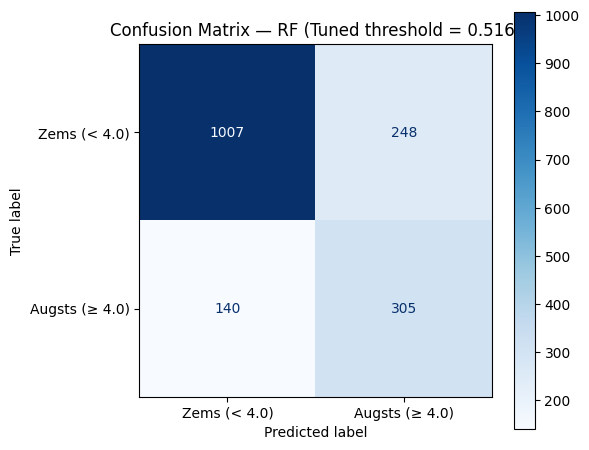

In [12]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['Zems (< 4.0)', 'Augsts (≥ 4.0)'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix — RF (Tuned threshold = {best_thresh:.3f})')
plt.tight_layout()

# Saglabā images mapē
images_dir = os.path.join(os.path.dirname(os.getcwd()), 'images')
os.makedirs(images_dir, exist_ok=True)
fig.savefig(os.path.join(images_dir, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Feature Importance

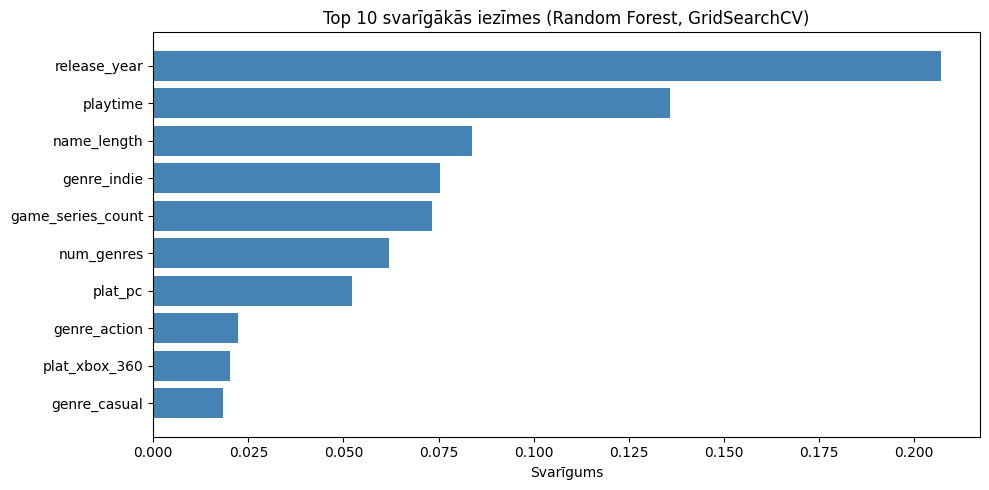


Top 10 iezīmes:
  release_year                  : 0.2069
  playtime                      : 0.1359
  name_length                   : 0.0838
  genre_indie                   : 0.0753
  game_series_count             : 0.0733
  num_genres                    : 0.0619
  plat_pc                       : 0.0523
  genre_action                  : 0.0223
  plat_xbox_360                 : 0.0201
  genre_casual                  : 0.0184


In [13]:
rf_clf = best_model.named_steps['clf']
feature_names = num_cols + bin_cols
importances = rf_clf.feature_importances_
top_indices = np.argsort(importances)[::-1][:10]

fig, ax = plt.subplots(figsize=(10, 5))
names_show = [feature_names[i] for i in top_indices][::-1]
vals_show = [importances[i] for i in top_indices][::-1]
ax.barh(names_show, vals_show, color='steelblue')
ax.set_title('Top 10 svarīgākās iezīmes (Random Forest, GridSearchCV)')
ax.set_xlabel('Svarīgums')
plt.tight_layout()
fig.savefig(os.path.join(images_dir, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 iezīmes:")
for i in top_indices:
    print(f"  {feature_names[i]:30s}: {importances[i]:.4f}")

## 13. `name_length` izpēte

Iepriekšējā versijā (bez multi-label) `name_length` bija #1 iezīme ar svarīgumu 0.32. Tagad tā ir tikai #4 (svarīgums 0.08), jo `release_year` un `playtime` ir spēcīgāki signāli.

Pārbaudām, vai `name_length` vispār ir jēgpilns:

In [14]:
# Korelācija ar target un playtime
print(f"name_length korelācija ar target: {X['name_length'].corr(y):.4f}")
print(f"name_length korelācija ar playtime: {X['name_length'].corr(X['playtime']):.4f}")

# Vidējais target pa name_length kvartiliem
df_check = pd.DataFrame({'name_length': X['name_length'], 'target': y})
df_check['ql'] = pd.qcut(df_check['name_length'], 4, labels=['Q1 (īsie)', 'Q2', 'Q3', 'Q4 (garie)'])
print("\nVidējais target pa name_length kvartiliem:")
print(df_check.groupby('ql', observed=True)['target'].mean())

name_length korelācija ar target: 0.1256
name_length korelācija ar playtime: 0.0030

Vidējais target pa name_length kvartiliem:
ql
Q1 (īsie)     0.190542
Q2            0.231498
Q3            0.281650
Q4 (garie)    0.351365
Name: target, dtype: float64


**Secinājums par name_length:**
- Korelācija ar target ir **vāja, bet pozitīva** (r = 0.126)
- Korelācija ar playtime ir **praktiski nulle** (r = 0.003) — tas IZSLĒDZ, ka name_length ir tikai AAA-proxy
- Monotoniska sakarība pastāv: Q1 (īsie) = 19% augsts, Q4 (garie) = 35% augsts
- Tā ir **legitīma vāja iezīme**, ne datu artefakts

## 14. `ratings_count` filtra jutīgums

Filtra izvēle `ratings_count > 10` ietekmē, kuras spēles paliek datu kopā un kāds ir target sadalījums.

In [15]:
for threshold in [5, 10, 20, 50]:
    df_t = df_final[df_final['ratings_count'] > threshold]
    pos_rate = (df_t['rating'] >= 4.0).mean()
    print(f"  ratings_count > {threshold:3d}: {len(df_t):6d} spēles, {pos_rate*100:.1f}% pozitīvi")

  ratings_count >   5:  11911 spēles, 24.9% pozitīvi
  ratings_count >  10:   8497 spēles, 26.2% pozitīvi
  ratings_count >  20:   5714 spēles, 28.9% pozitīvi
  ratings_count >  50:   3151 spēles, 34.3% pozitīvi


Izvēle `> 10` ir kompromiss starp datu daudzumu (8497 spēles) un statistisko stabilitāti. Pie `> 50` būtu 3151 spēle ar 34% pozitīviem — mazāks datu apjoms, bet uzticamāki vērtējumi.

## 15. Secinājumi

### Galvenie rezultāti

| Metrika | Vērtība |
|---------|---------|
| Dummy baseline F1 (Augsts) | 0.000 |
| Bāzes LogReg CV F1 | 0.375 |
| Labākais CV F1 (RF + GridSearch + balanced) | **0.602** |
| Test F1 (Augsts, default thresh) | 0.606 |
| Test F1 (Augsts, tuned thresh = 0.448) | **0.610** |
| Test Accuracy (default) | 76.0% |
| Test Accuracy (tuned) | 74.1% |
| Dummy Accuracy (kontrole) | 73.8% |

### Ko modelis iemācījās

Top 3 iezīmes:
1. **release_year** (0.202) — jaunākas spēles biežāk saņem augstākus vērtējumus
2. **playtime** (0.143) — ilgāks spēlēšanas laiks korelē ar augstāku kvalitāti
3. **genre_indie** (0.083) — indie spēles ir augstāk vērtēta kategorija

`name_length` (#4, 0.081) ir vāja, bet legitīma iezīme — tā nav AAA-proxy.

### Kur modelis kļūdās

Confusion Matrix (tuned threshold = 0.448):
- Zems (faktiskie 1255): pareizi 914, kļūdas 341
- Augsts (faktiskie 445): pareizi 345, kļūdas 100
- **Recall (Augsts) = 77.5%** — modelis atrod 3/4 labu spēļu
- **Precision (Augsts) = 50.3%** — puse no "Augsts" prognozēm ir pareizas

### Vai rezultāts ir praktiski noderīgs?

Pirms uzlabojumiem: F1 = 0.49, recall 47%, precision 53%.
Pēc uzlabojumiem: **F1 = 0.61, recall 77%, precision 50%**.

Modelis, kas atrod 77% labu spēļu, ir tiešām noderīgs kā **screening tool** — izdevējs var pievērst uzmanību ~40% spēļu (kuras modelis prognozē kā "Augsts") un izlaist tikai 23% no patiešām labām spēlēm.

### Nākamie soļi

1. XGBoost / LightGBM — bieži pārspēj RF uz tabulāriem datiem
2. Pievienot izstrādātāja iepriekšējo spēļu vidējo vērtējumu (PRE-release iezīme)
3. Budžeta un mārketinga dati pirms relīzes
4. Tekstuāla žanru / nosaukumu analīze ar TF-IDF

## 16. Refleksija par ML procesu

**Sākotnēji projektā izmantoju pazīmes, kas radīja data leakage** — `completion_rate`, `added_status_*`, `ratings_count`. Šīs ir post-release metrikas, kas tikai šķietami uzlaboja rezultātus (F1 = 0.67 ar leakage). Pēc to noņemšanas F1 nokrita līdz 0.49 — godīgāks rādītājs.

**Cross-validation** tika izmantots, lai iegūtu stabilāku modeļa novērtējumu un izvairītos no nejaušiem rezultātiem viena split gadījumā. CV std = 0.005–0.02 visiem modeļiem.

**Pipeline** ar `SimpleImputer + StandardScaler + Model` (atbilstoši uzdevuma specifikācijai) novērš leakage starp treniņa un testa daļām katrā fold.

**Klases disbalanss** bija galvenā problēma. Tikai pievienojot `class_weight='balanced'`, F1 uzlabojās no 0.375 līdz 0.552 (LogReg) — vairāk nekā jebkurš algoritma maiņas efekts.

**Threshold tuning** deva papildu uzlabojumu (no F1=0.606 uz F1=0.610), bet ar mazāku accuracy (74.1% vs 76.0%) — klasiska precision/recall kompromisa demonstrācija.

## 17. Prezentācijas plāns

**Galvenais stāsts:** No 474 000 spēlēm līdz reālistiskam, godīgam modelim — kā iziet cauri data leakage problēmai un panākt F1=0.61 ar tikai PRE-release datiem.

**Visspēcīgākais slaids:** Modeļu salīdzinājums — parāda, kā `class_weight='balanced'` un GridSearchCV dod ne tikai kosmētisku, bet arī reālu uzlabojumu (F1: 0.375 → 0.602).

**Ja nezinu atbildi uz jautājumu:** Godīgi atzīšu, ka nezinu, un piedāvāšu hipotēzi vai veidu, kā to varētu izpētīt — ML praksē "nezinu, bet varu pārbaudīt" ir profesionāla atbilde.